In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import shutil

In [ ]:
path = ('./dataset_gambar')

data = 'dataset_gambar'

In [ ]:
PATH = f'dataset_gambar/train'
train_ds = tf.keras.utils.image_dataset_from_directory(
    directory=PATH,
    batch_size=64,
    image_size=(256, 256),
    seed=42,
)

Found 6499 files belonging to 13 classes.


In [ ]:
class_names = train_ds.class_names
print(f'Class names: {class_names}')

all_labels = []
for _, label in train_ds.unbatch():
  all_labels.append(label.numpy())

all_labels = np.array(all_labels)

counts = np.bincount(all_labels, minlength=len(class_names))
for i, count in enumerate(counts):
  print(f'{class_names[i]}: {count}')

plt.bar(class_names, counts)
plt.title("Jumlah gambar per kelas")
plt.show()

NameError: name 'train_ds' is not defined

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(10, 10))
axes = axes.flatten()

images, labels = next(iter(train_ds))

for i in range(9):
  axes[i].imshow(images[i].numpy().astype("uint8"))
  axes[i].set_title(class_names[labels[i].numpy()])
  axes[i].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
for images, labels in train_ds.take(1):
  print(f'Image shape: {images.shape[1:]}')
  break

Image shape: (256, 256, 3)


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Normalization, Conv2D, MaxPooling2D, Dropout, Flatten, Dense, InputLayer, RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

In [ ]:
TRAIN_PATH = f'dataset_gambar/train'
train_ds, val_ds = tf.keras.utils.image_dataset_from_directory(
    directory=TRAIN_PATH,
    batch_size=64,
    image_size=(256, 256),
    validation_split=0.3,
    subset="both",
    seed=42,
    color_mode="rgb"
)

Found 6499 files belonging to 13 classes.
Using 4550 files for training.
Using 1949 files for validation.


In [ ]:
TEST_PATH = f'dataset_gambar/train'
test_ds = tf.keras.utils.image_dataset_from_directory(
    directory=TEST_PATH,
    batch_size=64,
    image_size=(256, 256),
    color_mode="rgb",
    seed=42,
)

Found 6499 files belonging to 13 classes.


In [ ]:
for images, labels in test_ds.take(1):
  input_shape = images.shape[1:]
  break

In [ ]:
norm_layer = Normalization()
norm_layer.adapt(data=train_ds.map(lambda x, y: x))

In [ ]:
data_augmentation = Sequential([
    RandomFlip("horizontal_and_vertical"),
    RandomRotation(0.2),
    RandomZoom(0.1)
])

model = Sequential([
    InputLayer((256, 256, 3)),   # <- fix here
    data_augmentation,
    norm_layer,
    Conv2D(32, 3, activation="relu", kernel_initializer="he_normal", kernel_regularizer=l2(0.0001)),
    MaxPooling2D(),
    Conv2D(64, 3, activation="relu", kernel_initializer="he_normal", kernel_regularizer=l2(0.0001)),
    MaxPooling2D(),
    Conv2D(64, 3, activation="relu", kernel_initializer="he_normal", kernel_regularizer=l2(0.0001)),
    MaxPooling2D(),
    Flatten(),
    Dense(128, activation="relu", kernel_initializer="he_normal", kernel_regularizer=l2(0.0001)),
    Dropout(0.2),
    Dense(64, activation="relu", kernel_initializer="he_normal", kernel_regularizer=l2(0.0001)),
    Dense(32, activation="relu", kernel_initializer="he_normal", kernel_regularizer=l2(0.0001)),
    Dense(len(train_ds.class_names), activation="softmax")
])


In [ ]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_8 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_4 (Normalization) │ (None, 256, 256, 3)    │             7 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 13)             │           429 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,440,020 (28.38 MB)

 Trainable params: 7,440,013 (28.38 MB)

 Non-trainable params: 7 (32.00 B)

In [ ]:
model.compile(
    optimizer=Adam(0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

In [ ]:
history = model.fit(train_ds, validation_data=val_ds, epochs=2, callbacks=[early_stopping])

Epoch 1/2
72/72 ━━━━━━━━━━━━━━━━━━━━ 40s 533ms/step - accuracy: 0.0829 - loss: 3.9254 - val_accuracy: 0.0652 - val_loss: 2.6558
Epoch 2/2
72/72 ━━━━━━━━━━━━━━━━━━━━ 39s 538ms/step - accuracy: 0.0820 - loss: 2.6535 - val_accuracy: 0.0652 - val_loss: 2.6519


In [ ]:
loss, accuracy = model.evaluate(test_ds)
print(f'Loss: {loss}, Accuracy: {accuracy}')

102/102 ━━━━━━━━━━━━━━━━━━━━ 13s 130ms/step - accuracy: 0.0769 - loss: 2.6514
Loss: 2.651416540145874, Accuracy: 0.07693491131067276


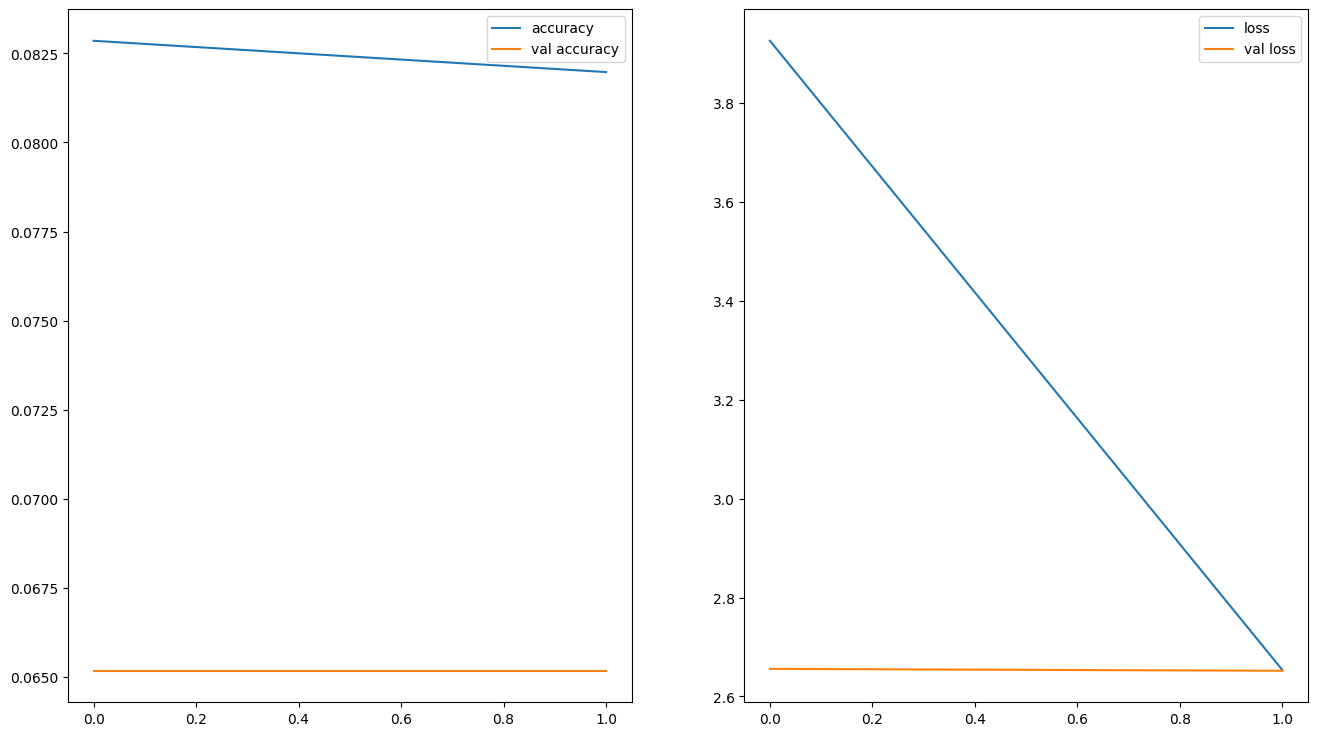

In [ ]:
plt.figure(figsize=(16, 9))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend(loc='best')
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend(loc='best')
plt.show()

In [ ]:
def create_model(dropout_rate: float) -> Sequential:
  data_augmentation = Sequential([
      RandomFlip("horizontal_and_vertical"),
      RandomRotation(0.2),
      RandomZoom(0.1)
  ])

  model = Sequential([
      InputLayer(input_shape),
      data_augmentation,
      norm_layer,
      Conv2D(32, 3, activation="relu", kernel_initializer="he_normal", kernel_regularizer=l2(0.0001)),
      MaxPooling2D(),
      Conv2D(64, 3, activation="relu", kernel_initializer="he_normal", kernel_regularizer=l2(0.0001)),
      MaxPooling2D(),
      Conv2D(64, 3, activation="relu", kernel_initializer="he_normal", kernel_regularizer=l2(0.0001)),
      MaxPooling2D(),
      Flatten(),
      Dense(128, activation="relu", kernel_initializer="he_normal", kernel_regularizer=l2(0.0001)),
      Dropout(dropout_rate),
      Dense(64, activation="relu", kernel_initializer="he_normal", kernel_regularizer=l2(0.0001)),
      Dense(32, activation="relu", kernel_initializer="he_normal", kernel_regularizer=l2(0.0001)),
      Dense(len(train_ds.class_names), activation="softmax")
  ])

  return model

In [ ]:
learning_rates = [0.001, 0.0001]
dropout_rates = [0.2, 0.3, 0.4]

results = []

for lr in learning_rates:
  for dr in dropout_rates:
    print(f"--- Testing: LR={lr}, Dropout={dr} ---")
    model = create_model(dr)

    model.compile(
        optimizer=Adam(lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    model.fit(train_ds, validation_data=val_ds, epochs=30, callbacks=[early_stopping], verbose=0)

    loss, accuracy = model.evaluate(test_ds, verbose=0)
    print(f"Test Accuracy: {accuracy:.4f}\n")

    results.append({
        'learning_rate': lr,
        'dropout_rate': dr,
        'val_accuracy': accuracy
    })

--- Testing: LR=0.001, Dropout=0.2 ---


NameError: name 'create_model' is not defined

In [ ]:
# === AUTO-GENERATED THUMBNAIL EXPORT ===
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import os

# Find all existing figure axes
figures = [plt.figure(i) for i in plt.get_fignums()]
if figures:
    fig = figures[-1]  # Use last figure
else:
    # Create a summary figure from available data
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.text(0.5, 0.5, 'Project Visualization', fontsize=24, 
            ha='center', va='center', transform=ax.transAxes,
            fontweight='bold', color='#2d3436')
    ax.set_facecolor('#f8f9fa')
    fig.patch.set_facecolor('#f8f9fa')
    ax.axis('off')

thumbnail_path = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'thumbnail.png')
fig.savefig(thumbnail_path, dpi=150, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
print(f"✅ Thumbnail saved: {thumbnail_path}")
plt.show()
